In [1]:
import pandas as pd


df = pd.read_excel("/Users/delphina/Downloads/YEAR 02/DSPL/DSPL 2/DSPL CW 2/What_a_Waste .xlsx", sheet_name="Country dataset", header=0)

print(df.head())
print(df.info())

  Country code                 Region   Country name   \
0        iso3c              region_id    country_name   
1          AFG                S. Asia     Afghanistan   
2          ALB      Eur. & Cent. Asia         Albania   
3          DZA  Mid. East & N. Africa         Algeria   
4          ASM      E. Asia & Pacific  American Samoa   

  Income group (waste generation year) Income group (2022)  \
0                            income_id      income_id_2022   
1                                  LIC                 LIC   
2                                 UMIC                UMIC   
3                                 LMIC                LMIC   
4                                 UMIC                 HIC   

                   GDP Population in waste generation year  \
0                  gdp         population_number_of_people   
1       18753456497.82                            35174083   
2          18032009220                             2865704   
3  164873415325.200012              

In [2]:
df = df.iloc[1:].copy()

In [3]:
print(df.columns.tolist())

['Country code', 'Region', 'Country name ', 'Income group (waste generation year)', 'Income group (2022)', 'GDP', 'Population in waste generation year', 'MSW generation - year reported', 'MSW generation (t/y)', 'MSW generation - point of measurement', 'MSW generation (kg/capita/day)', 'MSW generation - projected 2022 (t/year)', 'Population in 2022', 'MSW generation - projected 2022 (kg/cap/day)', 'MSW generation - projected 2030 (t/y)', 'Population in 2030', 'MSW generation - projected 2030 (kg/cap/day)', 'MSW generation - projected 2040 (t/y)', 'Population in 2040', 'MSW generation - projected 2040 (kg/cap/day)', 'MSW generation - projected 2050 (t/y)', 'Population in 2050', 'MSW generation - projected 2050 (kg/cap/day)', 'Composition - food  (% weight MSW)', 'Composition - glass  (% weight MSW)', 'Composition - metal (% weight MSW)', 'Composition - paper & cardboard (% weight MSW)', 'Composition - plastic (% weight MSW)', 'Composition - rubber & leather  (% weight MSW) ', 'Compositio

In [5]:
# Remove extra spaces 
df.columns = df.columns.str.strip()

print(df.columns.tolist())  # check exact names

['Country code', 'Region', 'Country name', 'Income group (waste generation year)', 'Income group (2022)', 'GDP', 'Population in waste generation year', 'MSW generation - year reported', 'MSW generation (t/y)', 'MSW generation - point of measurement', 'MSW generation (kg/capita/day)', 'MSW generation - projected 2022 (t/year)', 'Population in 2022', 'MSW generation - projected 2022 (kg/cap/day)', 'MSW generation - projected 2030 (t/y)', 'Population in 2030', 'MSW generation - projected 2030 (kg/cap/day)', 'MSW generation - projected 2040 (t/y)', 'Population in 2040', 'MSW generation - projected 2040 (kg/cap/day)', 'MSW generation - projected 2050 (t/y)', 'Population in 2050', 'MSW generation - projected 2050 (kg/cap/day)', 'Composition - food  (% weight MSW)', 'Composition - glass  (% weight MSW)', 'Composition - metal (% weight MSW)', 'Composition - paper & cardboard (% weight MSW)', 'Composition - plastic (% weight MSW)', 'Composition - rubber & leather  (% weight MSW)', 'Composition 

In [6]:
# Drop unwanted columns 
columns_to_keep = [
    'Country name',
    'Region',
    'Income group (waste generation year)',
    'GDP',
    'Population in waste generation year',
    'MSW generation - year reported',
    'MSW generation (t/y)',
    'MSW generation (kg/capita/day)',
    'Composition - food  (% weight MSW)',
    'Composition - paper & cardboard (% weight MSW)',
    'Composition - plastic (% weight MSW)',
    'Existence of rules and regulations for public-private partnerships'
]

df = df[columns_to_keep]

In [7]:
df = df.rename(columns={
    'Country name': 'country_name',
    'Region': 'region',
    'GDP': 'gdp',
    'Income group (waste generation year)': 'income_group',
    'Population in waste generation year': 'population',
    'MSW generation - year reported': 'year_reported',
    'MSW generation (t/y)': 'msw_tonnes_per_year',
    'MSW generation (kg/capita/day)': 'msw_kg_per_capita_per_day',
    'Composition - food  (% weight MSW)': 'composition_food(% weight MSW)',
    'Composition - paper & cardboard (% weight MSW)': 'composition_paper_cardboard(% weight MSW)',
    'Composition - plastic (% weight MSW)': 'composition_plastic(% weight MSW)',
    'Existence of rules and regulations for public-private partnerships': 'ppp_regulations'
})

In [8]:
df['region'] = df['region'].replace({
    'E. Asia & Pacific': 'East Asia and Pacific',
    'Eur. & Cent. Asia': 'Europe and Central Asia',
    'L. Amer. & the Caribbean': 'Latin America and Caribbean',
    'Mid. East & N. Africa': 'Middle East and North Africa',
    'N. Amer.': 'North America',
    'S. Asia': 'South Asia'
})

In [9]:
df['income_group'] = df['income_group'].replace({
    'HIC': 'high-income country',
    'LIC': 'low-income country',
    'LMIC': 'lower-middle-income country',
    'UMIC': 'upper-middle-income country'
})

In [10]:
# Convert to numeric columns 
cols_to_convert = [
    'gdp',
    'population',
    'msw_tonnes_per_year',
    'msw_kg_per_capita_per_day'
]

for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [11]:
#remove missing values
df = df.dropna()
# Remove rows with missing country names
df = df.dropna(subset=['country_name'])
df = df.dropna(subset=['gdp'])

# Fill numeric columns with median values
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

In [12]:
#remove duplicates
df = df.drop_duplicates()

In [13]:
df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')

print(df.columns)

Index(['country_name', 'region', 'income_group', 'gdp', 'population',
       'year_reported', 'msw_tonnes_per_year', 'msw_kg_per_capita_per_day',
       'composition_food%_weight_msw',
       'composition_paper_cardboard%_weight_msw',
       'composition_plastic%_weight_msw', 'ppp_regulations'],
      dtype='object')


In [ ]:
df.to_excel("/Users/delphina/Downloads/YEAR 02/DSPL/DSPL 2/DSPL CW 2/cleaned_what_a_waste_data.xlsx", index=False)

EDA

In [17]:
import pandas as pd

df = pd.read_excel("/Users/delphina/Downloads/YEAR 02/DSPL/DSPL 2/DSPL CW 2/cleaned_what_a_waste_data.xlsx")

print(df.shape)
print(df.info())
print(df.describe())

(145, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 12 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   country_name                             145 non-null    object 
 1   region                                   145 non-null    object 
 2   income_group                             145 non-null    object 
 3   gdp                                      145 non-null    float64
 4   population                               145 non-null    float64
 5   year_reported                            145 non-null    int64  
 6   msw_tonnes_per_year                      145 non-null    float64
 7   msw_kg_per_capita_per_day                145 non-null    float64
 8   composition_food%_weight_msw             145 non-null    float64
 9   composition_paper_cardboard%_weight_msw  145 non-null    float64
 10  composition_plastic%_weight_msw         

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df.isna().sum()

country_name                               0
region                                     0
income_group                               0
gdp                                        0
population                                 0
year_reported                              0
msw_tonnes_per_year                        0
msw_kg_per_capita_per_day                  0
composition_food%_weight_msw               0
composition_paper_cardboard%_weight_msw    0
composition_plastic%_weight_msw            0
ppp_regulations                            0
dtype: int64

In [20]:
df.sort_values('msw_tonnes_per_year', ascending=False).head(10)

,country_name,region,income_group,gdp,population,year_reported,msw_tonnes_per_year,msw_kg_per_capita_per_day,composition_food%_weight_msw,composition_paper_cardboard%_weight_msw,composition_plastic%_weight_msw,ppp_regulations
24,China,East Asia and Pacific,upper-middle-income country,1.831677e+13,1.426098e+09,2022,5.026074e+08,0.965576,0.59300,0.091000,0.121000,Yes
136,United States,North America,high-income country,2.065652e+13,3.336753e+08,2018,2.652608e+08,2.177992,0.21600,0.231000,0.122000,Yes
51,India,South Asia,lower-middle-income country,3.167271e+12,1.409264e+09,2021,2.022540e+08,0.393198,0.45000,0.074000,0.161000,Yes
15,Brazil,Latin America and Caribbean,upper-middle-income country,1.951924e+12,2.099058e+08,2022,8.181151e+07,1.067817,0.45300,0.104000,0.168000,Yes
52,Indonesia,East Asia and Pacific,upper-middle-income country,1.371169e+12,2.800265e+08,2023,5.543904e+07,0.542405,0.39710,0.107800,0.191500,Yes
41,Germany,Europe and Central Asia,high-income country,4.163596e+12,8.377156e+07,2022,4.969900e+07,1.625392,0.35487,0.200741,0.084728,Yes
92,Pakistan,South Asia,lower-middle-income country,3.748903e+11,2.417279e+08,2022,4.850000e+07,0.549695,0.56960,0.073700,0.097100,No
78,Mexico,Latin America and Caribbean,upper-middle-income country,1.316569e+12,1.272412e+08,2021,4.767061e+07,1.026432,0.33070,0.096200,0.123900,Yes
103,Russian Federation,Europe and Central Asia,upper-middle-income country,2.291612e+12,1.454844e+08,2022,4.586740e+07,0.863764,0.34000,0.190000,0.140000,Yes
87,Nigeria,Sub-Saharan Africa,lower-middle-income country,4.408336e+11,2.162515e+08,2021,4.450000e+07,0.563778,0.49780,0.127900,0.084000,No


Text(0.5, 1.0, 'Top 10 Countries by Total Municipal Solid Waste Generation')

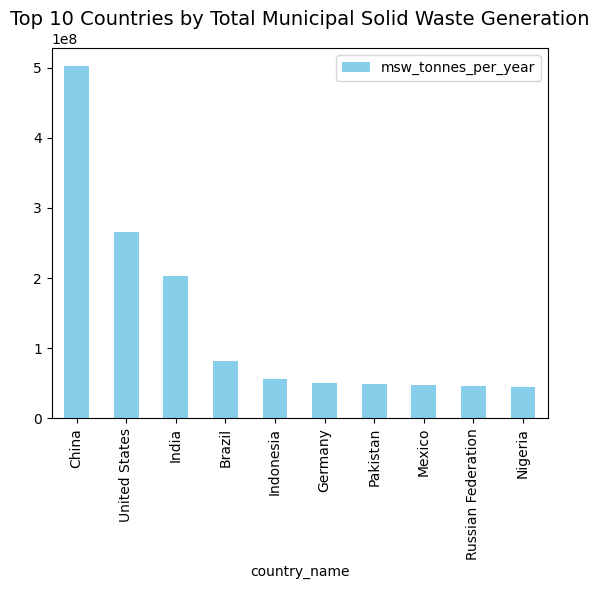

In [21]:
top10 = df.sort_values('msw_tonnes_per_year', ascending=False).head(10)
top10.plot(x='country_name', y='msw_tonnes_per_year', kind='bar', color='skyblue')
plt.title("Top 10 Countries by Total Municipal Solid Waste Generation", fontsize=14)

Univariate Analysis

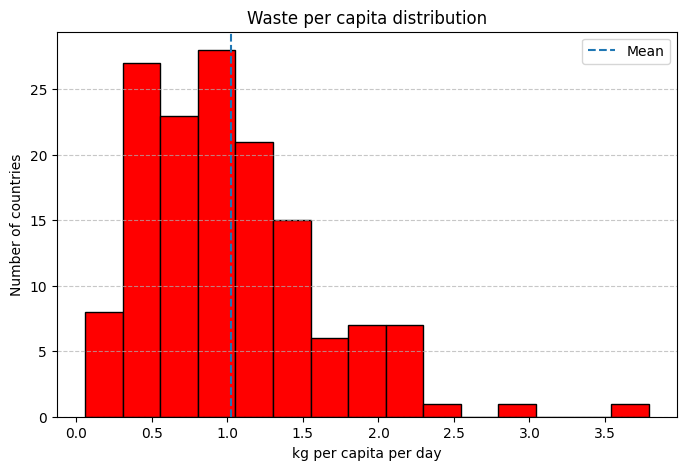

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(8,5))

plt.hist(df['msw_kg_per_capita_per_day'], bins=15,  color='red', edgecolor='black')

plt.title("Waste per capita distribution")
plt.xlabel("kg per capita per day")
plt.ylabel("Number of countries")
plt.axvline(df['msw_kg_per_capita_per_day'].mean(), linestyle='--', label='Mean')
plt.legend()

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

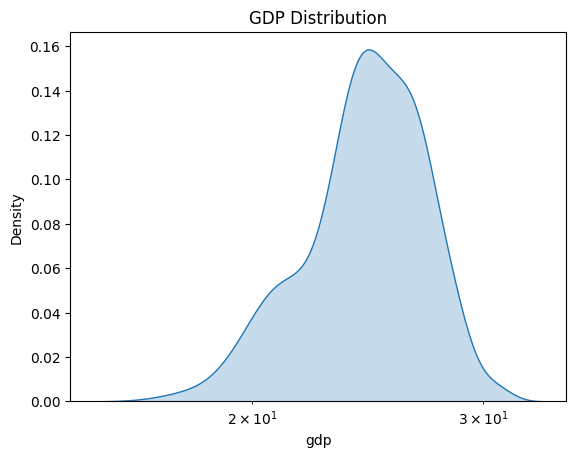

In [26]:
sns.kdeplot(np.log1p(df['gdp']), fill=True)
plt.xscale('log')
plt.title("GDP Distribution")
plt.show()

Bivariate Analysis

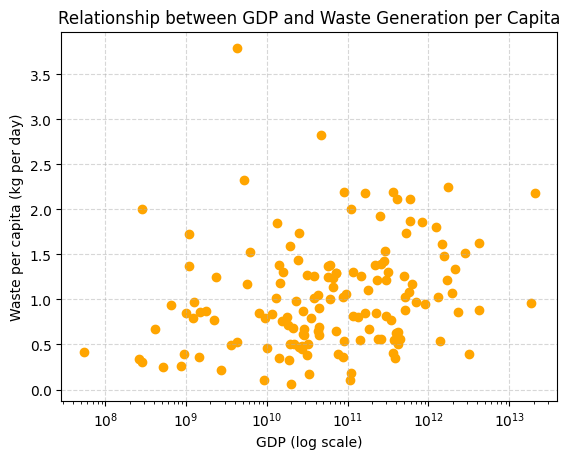

In [27]:
plt.scatter(df['gdp'], df['msw_kg_per_capita_per_day'], color='orange')
plt.xscale('log')
plt.grid(True, linestyle='--', alpha=0.5)
plt.title("Relationship between GDP and Waste Generation per Capita")
plt.xlabel("GDP (log scale)")
plt.ylabel("Waste per capita (kg per day)")
plt.show()


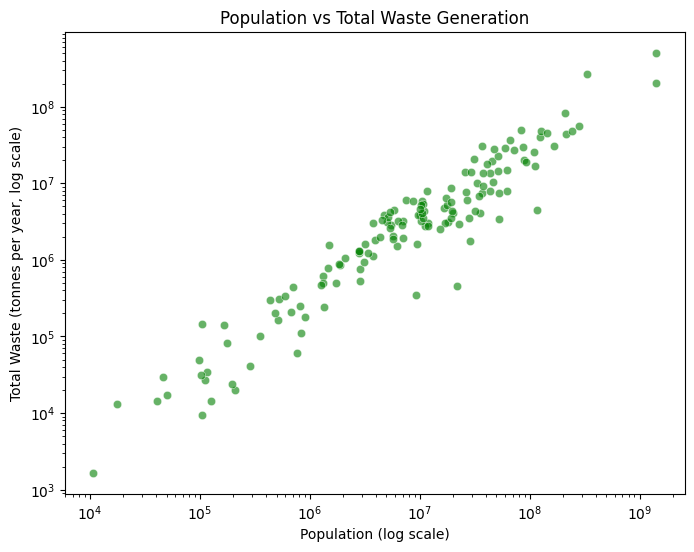

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='population',
    y='msw_tonnes_per_year',
    data=df,
    alpha=0.6,
    color='green'
)

plt.xscale('log')
plt.yscale('log')

plt.title("Population vs Total Waste Generation")
plt.xlabel("Population (log scale)")
plt.ylabel("Total Waste (tonnes per year, log scale)")

plt.show()

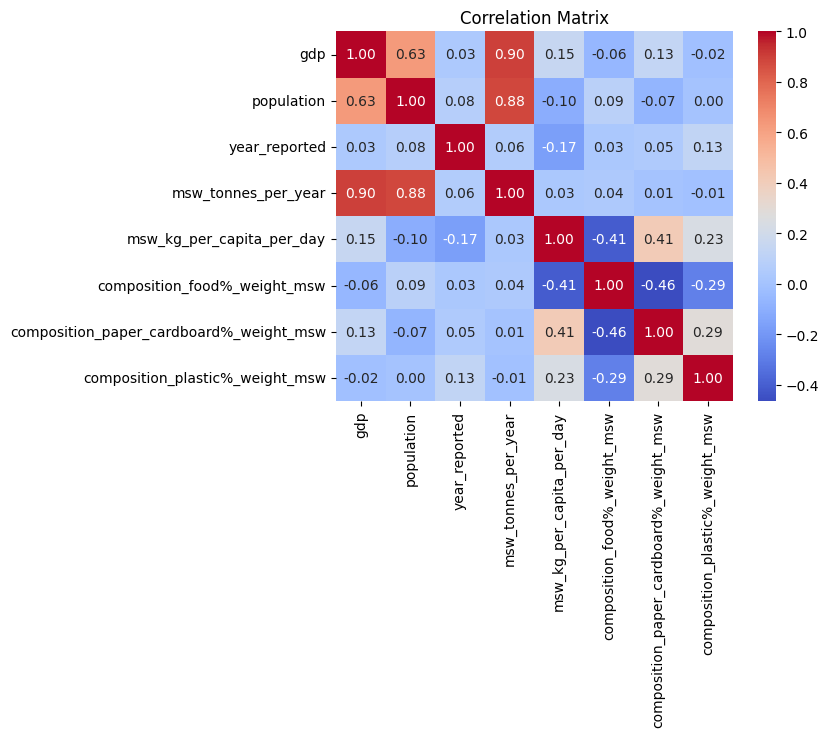

In [29]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')

plt.title("Correlation Matrix")
plt.show()

Multivariate Analysis

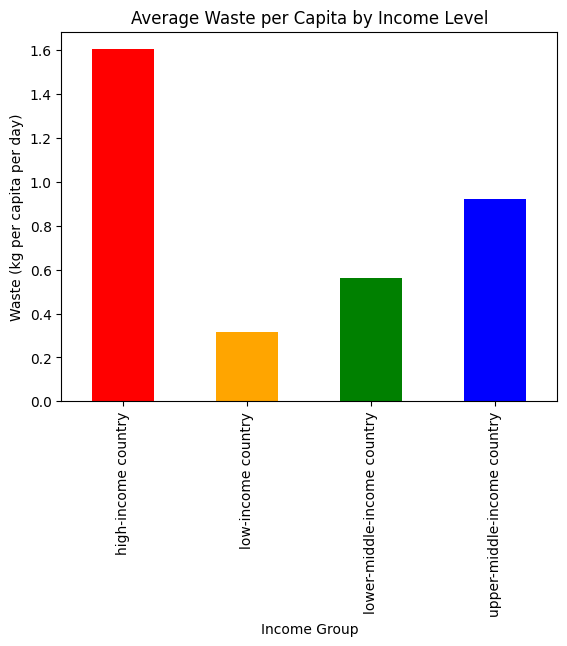

In [30]:
df_grouped = df.groupby('income_group')['msw_kg_per_capita_per_day'].mean()


df_grouped.plot(kind='bar', color=['red', 'orange', 'green', 'blue'])

plt.title("Average Waste per Capita by Income Level")
plt.xlabel("Income Group")
plt.ylabel("Waste (kg per capita per day)")

plt.show()

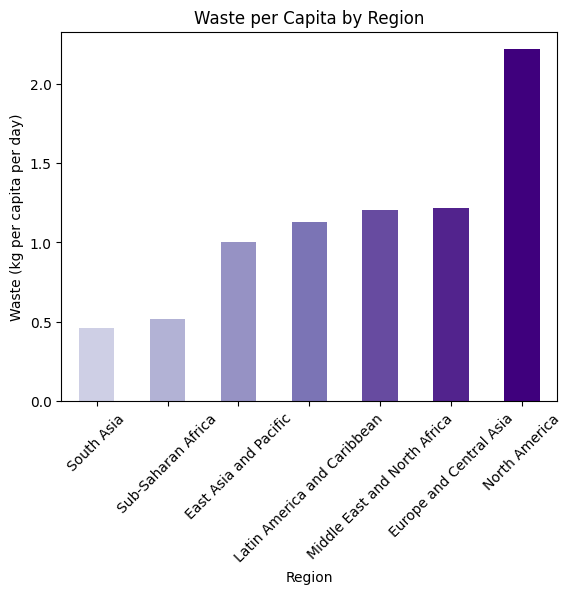

In [34]:
region_waste = df.groupby('region')['msw_kg_per_capita_per_day'].mean()
region_waste = region_waste.sort_values()


colors = plt.cm.Purples(np.linspace(0.3, 1, len(region_waste)))

region_waste.plot(kind='bar', color=colors)

plt.title("Waste per Capita by Region")
plt.xlabel("Region")
plt.ylabel("Waste (kg per capita per day)")
plt.xticks(rotation=45)

plt.show()

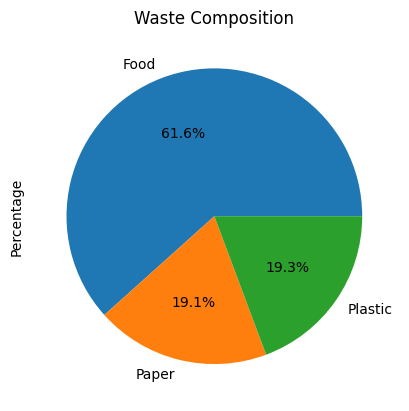

In [32]:
composition_cols = [
    'composition_food%_weight_msw',
    'composition_paper_cardboard%_weight_msw',
    'composition_plastic%_weight_msw'
]
labels = ['Food', 'Paper', 'Plastic']
df[composition_cols].mean().plot(kind='pie', labels=labels,autopct='%1.1f%%')

plt.title("Waste Composition")
plt.ylabel("Percentage")
plt.show()

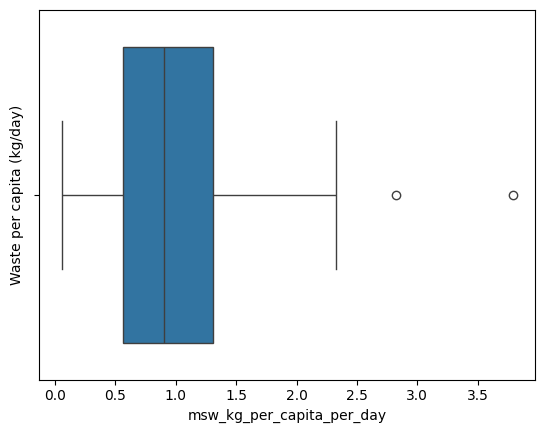

In [33]:
sns.boxplot(x=df['msw_kg_per_capita_per_day'])
plt.ylabel("Waste per capita (kg/day)")
plt.show()